# TCGA Classifiers


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [84]:
# Load data
X_train = pd.read_csv('../DATA/tcga/X_train.csv', index_col=0)
X_test = pd.read_csv('../DATA/tcga/X_test.csv', index_col=0)
y_train = pd.read_csv('../DATA/tcga/y_train.csv', index_col=0)["Variant_Type"]
y_test = pd.read_csv('../DATA/tcga/y_test.csv', index_col=0)["Variant_Type"]
y_train_initial = pd.read_csv('../DATA/tcga/y_train_initial.csv', index_col=0)["Variant_Type"]
y_test_initial = pd.read_csv('../DATA/tcga/y_test_initial.csv', index_col=0)["Variant_Type"]

In [79]:
mutations = pd.read_csv('../DATA/tcga/final_mutation_data.csv', index_col=0)
mutations

,Variant_Type
SP124190,WT
SP86425,WT
SP98359,WT
SP103144,WT
SP103225,WT
...,...
SP107776,WT
SP94060,SNP
SP17016,WT
SP79907,WT


## Selection of target genes

An important part of our analysis is the selection of genes that are connected to the mutated/non-mutated conditions of TP53 to make our prediction.

We identified a list of TP53 target genes—genes whose expression is directly regulated by the TP53 protein. To make predictions, we aim to select a subset of these target genes.

For selection, we rank the target genes based on the absolute value of their Spearman correlation coefficients: for each gene, we calculate the Spearman correlation coefficient with the target variable. Spearman correlation measures the relationship between two variables, providing insight into how changes in one variable are related to changes in another. We only retain genes where the p-value of the correlation is less than or equal to 0.001. This threshold ensures that we focus on genes with statistically significant correlations, reducing the risk of selecting genes with weak or insignificant relationships to the target variable. Finally, we select the top 100 genes with the highest absolute Spearman correlation coefficients. These genes are most strongly associated with the target variable.

Additionally, we explore another approach where we rank all the genes in our dataset according to their Spearman correlation coefficient (not limited to just TP53 target genes) and select a subset of these for classifier construction. We evaluate the performance of both methods to determine which yields the best results.

Our analysis begins by selecting a subset of TP53 target genes with the highest absolute Spearman correlation coefficients.

In [24]:
target_genes = [
    'CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2',
    'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB',
    'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1',
    'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1',
    'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'GDF15', 'DRAM1',
    'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6',
    'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1',
    'POU3F1', 'TSGA10', 'DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1',
    'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1',
    'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2',
    'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1',
    'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3',
    'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B',
    'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4',
    'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A', 'TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA',
    'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79',
    'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7',
    'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF',
    'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1',
    'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2',
    'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8',
    'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1',
    'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3',
    'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1',
    'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3',
    'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1',
    'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2',
    'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1',
    'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3',
    'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA',
    'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2',
    'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1',
    'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2',
    'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15',
    'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B'
]

### TP53 Target Genes Approach

We first filter our dataset to only include known TP53 target genes:

In [25]:
# Filter dataset to only include genes that exist in X_train
available_genes = [gene for gene in target_genes if gene in X_train.columns]
selected_dataset = X_train[available_genes]
selected_dataset.shape

(962, 335)

From these target genes, we select the top 100 most significantly correlated with TP53 status using Spearman correlation (p ≤ 0.001):

In [31]:
from scipy.stats import spearmanr


def select_genes_spearman(dataset):
    correlations = []
    p_values = []
    selected_genes = []
    for column in dataset.columns:
        corr, p_value = spearmanr(dataset[column], y_train)
        if p_value <= 0.001:
            correlations.append(corr)
            p_values.append(p_value)
            selected_genes.append(column)

    corr_results = pd.DataFrame({
        'Gene': selected_genes,
        'Spearman_Correlation': correlations,
        'P_Value': p_values
    })
    corr_results['Abs_Correlation'] = corr_results['Spearman_Correlation'].abs()
    corr_results = corr_results.sort_values(by='Abs_Correlation', ascending=False)

    selected_genes = corr_results.head(100)['Gene'].tolist()
    return selected_genes

In [32]:
# selected genes among the target ones
selected_target_genes = select_genes_spearman(selected_dataset)
print(selected_target_genes)
print(len(selected_target_genes))

['RPS27L', 'XPC', 'EDA2R', 'SAC3D1', 'MDM2', 'ZMAT3', 'DDB2', 'CPEB4', 'TNFRSF10B', 'RRM2B', 'SCRIB', 'GRHL3', 'SESN1', 'PCNA', 'CFLAR', 'FCHO2', 'DOCK8', 'RGMA', 'PLCL2', 'AEN', 'ISCU', 'CCDC51', 'TRIM22', 'CYFIP2', 'MR1', 'MON2', 'CPEB2', 'BTG3', 'PVRL4', 'GCC2', 'TNFRSF10D', 'EI24', 'SFN', 'SPATA18', 'ANKRA2', 'FBXW7', 'ZNF488', 'SERPINB5', 'FAS', 'TEP1', 'RBM38', 'SLC25A45', 'PERP', 'KRT15', 'E2F7', 'PLTP', 'AKAP9', 'BMP7', 'MLF2', 'CDKN1A', 'COL7A1', 'NLRP1', 'TNFRSF10C', 'EPN3', 'PTPRE', 'S100A2', 'HES2', 'PGPEP1', 'BTG1', 'SNX2', 'CLP1', 'SLC12A4', 'TNFAIP8', 'ZNF79', 'BBS2', 'SDPR', 'COBLL1', 'TP53INP1', 'CPSF4', 'LIMK2', 'PLCXD2', 'TMEM63B', 'SLC4A11', 'TET2', 'DUSP11', 'BBC3', 'PLXNB1', 'INPP1', 'CCNK', 'DDR1', 'ENPP2', 'FUCA1', 'PLEKHF1', 'CES2', 'DUSP7', 'CDIP1', 'TSKU', 'NYNRIN', 'IGFBP7', 'MYBPHL', 'MRPL49', 'CEL', 'APAF1', 'STEAP3', 'CROT', 'APOBEC3H', 'TMEM68', 'TRIM5', 'CASP6', 'LPXN']
100


In [33]:
X_train_target_genes = X_train[selected_target_genes]
X_train_target_genes

,RPS27L,XPC,EDA2R,SAC3D1,MDM2,ZMAT3,DDB2,CPEB4,TNFRSF10B,RRM2B,...,MRPL49,CEL,APAF1,STEAP3,CROT,APOBEC3H,TMEM68,TRIM5,CASP6,LPXN
SP80183,26.312925,10.432699,2.005807,8.002328,8.495900,3.927704,13.637042,3.757798,5.884977,7.200065,...,24.338480,0.564537,1.348353,8.040472,10.449131,0.531431,3.621198,4.828414,13.400929,9.484566
SP92332,16.163450,6.906921,0.599643,8.760151,11.942727,2.252155,9.136481,2.676314,22.866055,3.346141,...,6.027399,0.977527,0.609903,4.341253,6.013258,1.199801,9.086611,4.316259,24.156229,6.004058
SP127632,30.823944,13.178268,0.704839,21.137829,14.233125,8.552836,89.890195,1.358669,11.607174,6.007184,...,21.071668,0.329514,1.389842,2.429268,1.681814,11.169435,1.609260,3.248443,5.611646,110.697694
SP97194,16.168824,14.547499,4.599005,3.768736,24.977357,7.893454,49.306478,7.724645,47.234804,7.541684,...,32.409581,0.086004,1.681202,12.302195,2.232514,0.304376,2.848903,4.823598,12.806963,7.782661
SP28275,12.776280,11.137506,6.030118,7.211509,13.515783,12.865010,17.990282,6.430100,14.579584,10.240664,...,22.799748,0.345446,3.659857,15.473199,9.327629,1.020747,3.472781,7.044372,5.955372,12.944105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SP87099,22.026062,14.323316,4.678840,2.917620,13.826152,4.808546,7.057857,15.588371,9.716577,37.771964,...,26.775861,0.112421,2.160013,13.152643,22.097397,0.096752,4.294013,5.690073,8.114110,3.581567
SP24236,20.131689,8.483330,2.991448,6.390416,11.973211,7.222454,11.510053,6.293801,5.691508,16.023656,...,32.936340,0.206723,2.212904,21.963938,13.942836,0.456620,4.689494,4.543055,10.807200,7.831801
SP30071,4.949805,9.742755,0.664757,8.015388,13.040377,1.996784,25.943630,5.214060,16.057193,6.010096,...,27.252318,0.416908,2.722858,8.835124,5.658584,0.794491,1.767601,12.190101,6.326194,9.873840
SP115162,13.756916,10.268054,0.206831,7.101503,10.320619,3.464954,28.393407,3.820936,26.758517,7.945569,...,21.492124,4.245021,2.467537,8.044585,3.546246,0.820588,4.704013,8.115975,17.568810,4.317194


In [34]:
X_test_target_genes = X_test[selected_target_genes]

For comparison, we also apply the Spearman correlation method to all genes to select the top 100 most correlated genes.

In [35]:
# selected genes among all the ones present in the dataset
selected_genes = select_genes_spearman(X_train)
print(selected_genes)
print(len(selected_genes))

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_30933/4212679094.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(dataset[column], y_train)


['UBE2C', 'AUNIP', 'TRIP13', 'FAM83D', 'TTK', 'CBX2', 'TPX2', 'ECE2', 'CDC20', 'FOXM1', 'CENPA', 'CDCA5', 'CENPW', 'CDCA8', 'BIRC5', 'ACTL6A', 'HDGF', 'TROAP', 'CDCA3', 'AURKA', 'ZNF695', 'CSE1L', 'CCNB2', 'KIF2C', 'HJURP', 'MRPL3', 'USP39', 'PLK1', 'DSCC1', 'CCT5', 'DPH2', 'STIP1', 'GINS1', 'PSRC1', 'RCC1', 'TICRR', 'UBE2T', 'KIFC1', 'SKP2', 'SKA3', 'KPNA2', 'NEK2', 'FAM64A', 'NCAPH', 'ALG3', 'MCM10', 'XPO5', 'BYSL', 'RAD54L', 'MTFR2', 'RPP40', 'MELK', 'KIF20A', 'CDC25C', 'CMSS1', 'CKS1B', 'KIF4A', 'TRAIP', 'CCNB1', 'CDK1', 'BUB1', 'CKS2', 'XRCC2', 'OIP5', 'RFC4', 'C11orf82', 'KIF18B', 'NUF2', 'LSM4', 'BEND3', 'RUVBL1', 'RPS27L', 'CDC123', 'RNASEH2A', 'MYBL2', 'MIS18A', 'DEPDC1', 'KIF23', 'SPC24', 'POC1A', 'CTSV', 'MCM2', 'E2F1', 'ASF1B', 'VPS72', 'MEX3A', 'ESPL1', 'PUF60', 'HDAC2', 'PDCD2L', 'MRTO4', 'FLAD1', 'DCAF13', 'AC104651.1', 'PSMB2', 'SPC25', 'SYNE1', 'EGFL6', 'CEP55', 'DCUN1D5']
100


In [36]:
X_train_subset = X_train[selected_genes]
X_test_subset = X_test[selected_genes]

## Models

### Binary classifier

Our initial approach is to construct a binary classifier aimed at predicting whether TP53 is mutated or not. The prediction model relies solely on the subset of genes we selected earlier — first using the subset of TP53 target genes and later using the second subset of all genes. We will then compare the performance of these two subsets to evaluate which provides the most accurate predictions.

Classifiers implemented:
* Random Forest: effective for high-dimensional data and captures complex interactions
* Logistic Regression: simple baseline model with good interpretability
* Support Vector Machine: works well with high-dimensional data
* K-Nearest Neighbors: might capture local patterns
* XGBoost: powerful gradient boosting method often top-performing
* Neural Network (MLP): can model complex non-linear relationships

Each classifier is implemented with grid search for hyperparameter tuning.

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV

In [54]:
# Random Forest

def random_forest(X_train, y_train):

    param_grid_rf = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['log2', 'sqrt']
    }

    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid_rf,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_rf.fit(X_train, y_train)

    best_params_rf = grid_search_rf.best_params_
    print("Best Random Forest Parameters:", best_params_rf)


    best_rf = grid_search_rf.best_estimator_
    return best_rf

In [99]:
# Logistic Regression

def logistic_regression(X_train, y_train):
 
    param_grid_lr = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }

    grid_search_lr = GridSearchCV(
        estimator=LogisticRegression(random_state=42, max_iter=1000),
        param_grid=param_grid_lr,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_lr.fit(X_train, y_train)

    best_params_lr = grid_search_lr.best_params_
    print("Best Logistic Regression Parameters:", best_params_lr)

    best_lr = grid_search_lr.best_estimator_
    return best_lr

In [75]:
# Support Vector Machine

def svm(X_train, y_train):
   
    param_grid_svc = {
        'C': [1, 10],
        'kernel': ['rbf', 'poly'],
        'gamma': ['scale', 0.1, 1]
    }

    grid_search_svc = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid_svc,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_svc.fit(X_train, y_train)

    best_params_svc = grid_search_svc.best_params_
    print("Best SVM Parameters:", best_params_svc)

    best_svc = grid_search_svc.best_estimator_
    return best_svc

In [76]:
# K-Nearest Neighbors

def knn(X_train, y_train):
  
    param_grid_knn = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }

    grid_search_knn = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid_knn,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_knn.fit(X_train, y_train)

    best_params_knn = grid_search_knn.best_params_
    print("Best KNN Parameters:", best_params_knn)

    best_knn = grid_search_knn.best_estimator_
    return best_knn

In [104]:
# XGBoost
def xgboost(X_train, y_train):
    param_grid_xgb_binary = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }


    xgb = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )


    grid_search_xgb = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid_xgb_binary,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_xgb.fit(X_train, y_train)

    print("Best XGBoost Parameters:", grid_search_xgb.best_params_)

    best_xgb = grid_search_xgb.best_estimator_
    return best_xgb

In [74]:
# Neural Network (MLP)

def neural_netw(X_train, y_train):
    param_grid_nn = {
        'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam', 'sgd'],
        'alpha': [0.0001, 0.001, 0.01], 
        'learning_rate': ['constant', 'adaptive']
    }

    grid_search_nn = GridSearchCV(
        estimator=MLPClassifier(max_iter=1000, random_state=42),
        param_grid=param_grid_nn,
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_nn.fit(X_train, y_train)

    best_params_nn = grid_search_nn.best_params_
    print("Best Neural Network Parameters:", best_params_nn)

    best_nn = grid_search_nn.best_estimator_
    return best_nn

Models are evaluated on the test set using accuracy, precision, recall, and F1 score.

In [55]:
best_rf = random_forest(X_train_target_genes, y_train)
y_pred_rf = best_rf.predict(X_test_target_genes)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}


In [56]:
best_lr = logistic_regression(X_train_target_genes, y_train)
y_pred_lr = best_lr.predict(X_test_target_genes)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l1, sol

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.

[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   0.5s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   0.5s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   0.5s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   0.5s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   0.5s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   0.6s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   0.6s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   0.6s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   0.6s
[CV] END ................C=0

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................C=0.01, penalty=l1, solver=saga; total time=   0.6s
[CV] END ....................C=0.01, penalty=l1, solver=saga; total time=   0.6s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ....................C=0.01, penalty=l2, solver=saga; total time=   0.5s
[CV] END ....................C=0.01, penalty=l2, solver=saga; total time=   0.5s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ...................

...

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=100, penalty=l1, solver=saga; total time=   0.6s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.7s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.4s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.4s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.6s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.8s
[CV] END .....................C=100, penalty=l1, solver=saga; total time=   0.5s
[CV] END .....................C=100, penalty=l1, solver=saga; total time=   0.5s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.4s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.4s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.4s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.4s
Best Logistic Regression Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [57]:
best_svc = svm(X_train_target_genes, y_train)
y_pred_svc = best_svc.predict(X_test_target_genes)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1

In [58]:
best_knn = knn(X_train_target_genes, y_train)
y_pred_knn = best_knn.predict(X_test_target_genes)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s

[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.1s
[CV] END ...metric=euclidean, n_neighbors=5, we

In [59]:
best_xgb = xgboost(X_train_target_genes, y_train)
y_pred_xgb = best_xgb.predict(X_test_target_genes)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:45] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:45] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:45] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estima

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:45] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:45] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:45] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.5s


...

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100,

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:52] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:52] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:52] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.5s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:52] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:52] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:05:52] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200,

In [60]:
best_nn = neural_netw(X_train_target_genes, y_train)
y_pred_nn = best_nn.predict(X_test_target_genes)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   0.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   0.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   0.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.5s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   0.5s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constan

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.2s
[CV]

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   0.9s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.6s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.0s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100, 50), learning_rate=adaptive, solver=adam; total time=   0.2s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.2s
[CV] END act

...

[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=sgd; total time=   1.1s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.5s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.0s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.6s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.7s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100, 50), learning_rate=constant, solver=adam; total time=   0.6s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100, 50), learning_rate=adaptive, solver=adam; total time=   0.2s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=sgd; total time=   1.0s
[CV] END activation=

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   1.5s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.1s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   0.8s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.7s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.2s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=sgd; total time=   1.2s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   0.9s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.3s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=sgd; total time=   1.7s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.1s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=sgd; total time=   1.8s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.1s
[CV] END activation

In [61]:
classifiers = [
    ("Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf),
    ("Logistic Regression", accuracy_lr, precision_lr, recall_lr, f1_lr),
    ("SVM", accuracy_svc, precision_svc, recall_svc, f1_svc),
    ("K-Nearest Neighbors", accuracy_knn, precision_knn, recall_knn, f1_knn),
    ("XGBoost", accuracy_xgb, precision_xgb, recall_xgb, f1_xgb),
    ("Neural Network (MLP)", accuracy_nn, precision_nn, recall_nn, f1_nn)
]

for clf_name, accuracy, precision, recall, f1 in classifiers:
    print(f"{clf_name} Performance:")
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}\n")

Random Forest Performance:
  Accuracy: 0.8755 | Precision: 0.8676 | Recall: 0.7375 | F1 Score: 0.7973

Logistic Regression Performance:
  Accuracy: 0.8423 | Precision: 0.7763 | Recall: 0.7375 | F1 Score: 0.7564

SVM Performance:
  Accuracy: 0.8423 | Precision: 0.8000 | Recall: 0.7000 | F1 Score: 0.7467

K-Nearest Neighbors Performance:
  Accuracy: 0.8589 | Precision: 0.8108 | Recall: 0.7500 | F1 Score: 0.7792

XGBoost Performance:
  Accuracy: 0.8797 | Precision: 0.8400 | Recall: 0.7875 | F1 Score: 0.8129

Neural Network (MLP) Performance:
  Accuracy: 0.8216 | Precision: 0.7467 | Recall: 0.7000 | F1 Score: 0.7226



In [62]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_nn = confusion_matrix(y_test, y_pred_nn)

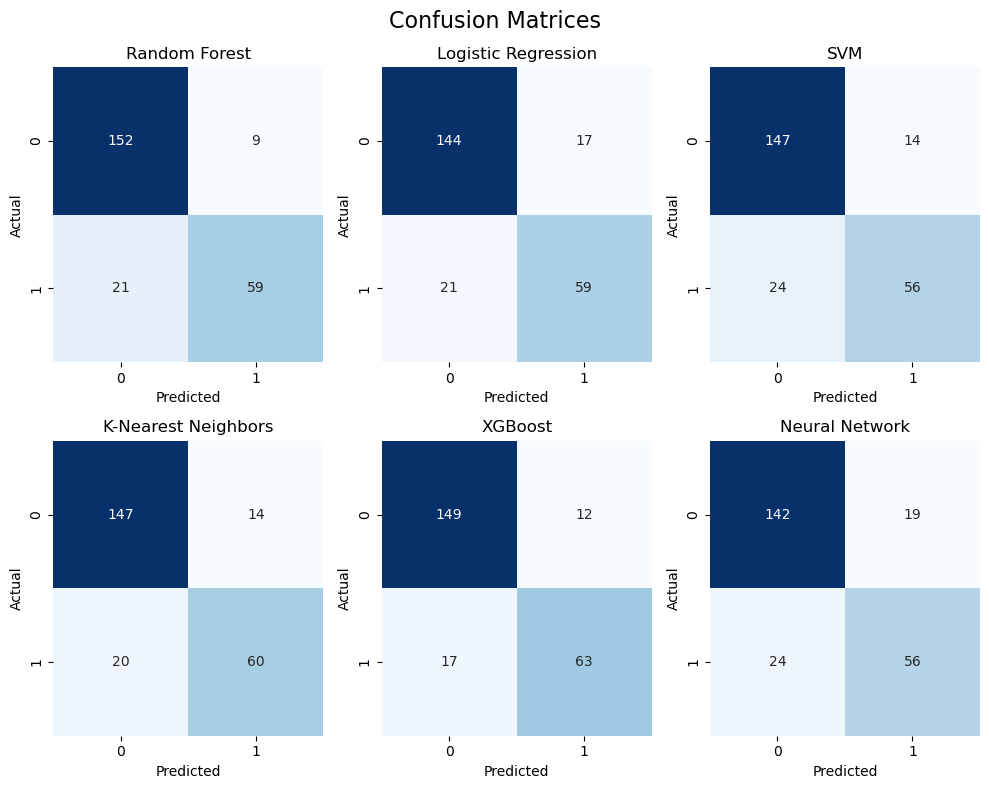

In [63]:
classifier_names = [
    'Random Forest', 'Logistic Regression', 'SVM',
    'K-Nearest Neighbors', 'XGBoost', 'Neural Network'
]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
fig.suptitle('Confusion Matrices', fontsize=16)

axes = axes.ravel()


for i, (cm, name) in enumerate(zip(
    [cm_rf, cm_lr, cm_svc, cm_knn, cm_xgb, cm_nn],
    classifier_names
)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Overall the best F1 score is achieved by XGBoost Parameters with parameters{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

We now assess the performance of the same classifiers, but this time trained on a dataset that includes a subset of genes with the highest absolute Spearman correlations, without limiting the selection to target genes.

In [64]:
best_rf = random_forest(X_train_subset, y_train)
y_pred_rf = best_rf.predict(X_test_subset)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}


In [65]:
best_lr = logistic_regression(X_train_subset, y_train)
y_pred_lr = best_lr.predict(X_test_subset)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   0.0s
[CV] END ...................C=0.001, penalty=l1

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ....................C=0.01, penalty=l1, solver=saga; total time=   0.3s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ....................C=0.01, penalty=l1, solver=saga; total time=   0.4s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.1s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.

[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   0.4s
[CV] END ..................C=1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   0.4s
[CV] END .....................C=0.1, penalty=l2, solver=saga; total time=   0.4s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=   0.6s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=   0.6s
[CV] END ....................C=0.01, penalty=l2, solver=saga; total time=   0.4s
[CV] END ..................C=1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..................C=1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END .....................C=0.1, penalty=l1, solver=saga; total time=   0.7s
[CV] END ....................C=0.01, penalty=l2, solver=saga; total time=   0.4s
[CV] END .................C=10, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END .................C=

...

[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.3s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=100, penalty=l1, solver=saga; total time=   0.4s
[CV] END ......................C=10, penalty=l2, solver=saga; total time=   0.3s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=100, penalty=l2, solver=saga; total time=   0.3s
Best Logistic Regression Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}


In [66]:
best_svc = svm(X_train_subset, y_train)
y_pred_svc = best_svc.predict(X_test_subset)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END ......................C=1, gamma=scale,

In [67]:
best_knn = knn(X_train_subset, y_train)
y_pred_knn = best_knn.predict(X_test_subset)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, we

In [68]:
best_xgb = xgboost(X_train_subset, y_train)
y_pred_xgb = best_xgb.predict(X_test_subset)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:20] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:20] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:20] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:20] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:20] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:20] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.4s


...

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1.0; total time=   1.0s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:25] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:26] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:26] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1.0; total time=   1.1s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:26] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:26] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:08:26] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1.0; total time=   1.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=200

In [69]:
best_nn = neural_netw(X_train_subset, y_train)
y_pred_nn = best_nn.predict(X_test_subset)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=adam; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=consta

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anacond

[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   1.8s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(100, 100), learning_rate=adaptive, solver=sgd; total time=   3.3s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   1.3s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.2s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.2s
[CV] END activation

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.9s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   2.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   2.0s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.9s


...

[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=constant, solver=sgd; total time=   1.8s
[CV] END activation=tanh, alpha=0.001, hidden_layer_sizes=(100, 100), learning_rate=adaptive, solver=sgd; total time=   4.6s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   0.9s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=adam; total time=   1.4s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   0.8s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.7s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.7s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.8s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(50,), learning_rate=adaptive, solver=sgd; total time=   1.8s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   0.9s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=adaptive, solver=adam; total time=   1.0s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=sgd; total time=   2.6s
[CV] END activation=tanh, alpha=0.01, hidden_layer_sizes=(100,), learning_rate=constant, solver=sgd; total time=   2.5s
[CV] END activation=tanh, alpha=0.01

In [70]:
classifiers = [
    ("Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf),
    ("Logistic Regression", accuracy_lr, precision_lr, recall_lr, f1_lr),
    ("SVM", accuracy_svc, precision_svc, recall_svc, f1_svc),
    ("K-Nearest Neighbors", accuracy_knn, precision_knn, recall_knn, f1_knn),
    ("XGBoost", accuracy_xgb, precision_xgb, recall_xgb, f1_xgb),
    ("Neural Network (MLP)", accuracy_nn, precision_nn, recall_nn, f1_nn)
]

for clf_name, accuracy, precision, recall, f1 in classifiers:
    print(f"{clf_name} Performance:")
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}\n")

Random Forest Performance:
  Accuracy: 0.8050 | Precision: 0.7200 | Recall: 0.6750 | F1 Score: 0.6968

Logistic Regression Performance:
  Accuracy: 0.8465 | Precision: 0.8028 | Recall: 0.7125 | F1 Score: 0.7550

SVM Performance:
  Accuracy: 0.8340 | Precision: 0.8125 | Recall: 0.6500 | F1 Score: 0.7222

K-Nearest Neighbors Performance:
  Accuracy: 0.8050 | Precision: 0.7538 | Recall: 0.6125 | F1 Score: 0.6759

XGBoost Performance:
  Accuracy: 0.8465 | Precision: 0.7722 | Recall: 0.7625 | F1 Score: 0.7673

Neural Network (MLP) Performance:
  Accuracy: 0.8174 | Precision: 0.7250 | Recall: 0.7250 | F1 Score: 0.7250



In [71]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_nn = confusion_matrix(y_test, y_pred_nn)

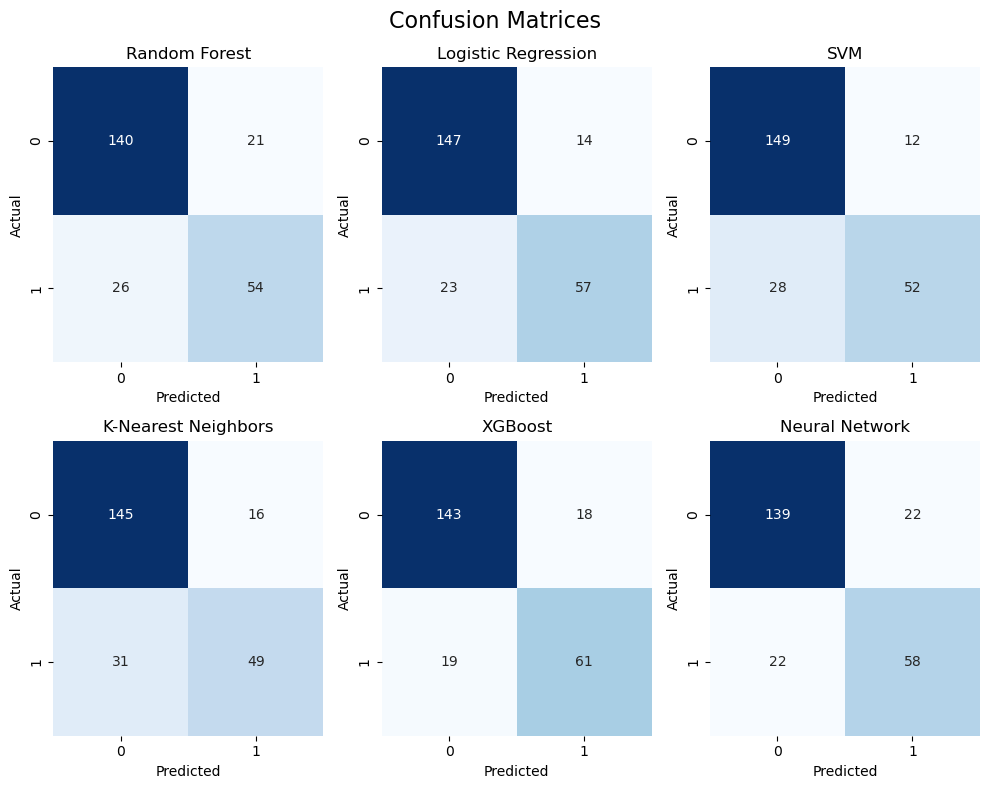

In [72]:
# Classifier names for titles
classifier_names = [
    'Random Forest', 'Logistic Regression', 'SVM',
    'K-Nearest Neighbors', 'XGBoost', 'Neural Network'
]

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
fig.suptitle('Confusion Matrices', fontsize=16)

# Flatten axes for easy iteration
axes = axes.ravel()

# Plot each confusion matrix
for i, (cm, name) in enumerate(zip(
    [cm_rf, cm_lr, cm_svc, cm_knn, cm_xgb, cm_nn],
    classifier_names
)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

The performance of the models trained on the top 100 genes—selected based on absolute Spearman correlation without restricting to TP53 target genes—is comparable to that of models trained solely on the TP53 target gene subset. This indicates that the subset of selected target genes is informative and effective for addressing the binary classification task.

The highest overall F1 score is obtained using a Random Forest model trained on the TP53 target gene subset with optimized hyperparameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}. Performance: Accuracy: 0.8569 | Precision: 0.7701 | Recall: 0.8306 | F1 Score: 0.7992

### Multi-class classifier
We repeat the same procedure, trying now to predict the specific mutation of TP53.

We use the same subsets of genes selected before to make our predictions.

In [85]:
len(mutations['Variant_Type'].unique())

5

In [86]:
y_train = y_train_initial
y_test = y_test_initial

In [87]:
print(f"Training data shape: {X_train.shape}")
print(f"Training labels distribution:\n{y_train.value_counts()}")
print()
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels distribution:\n{y_test.value_counts()}")

Training data shape: (962, 55851)
Training labels distribution:
Variant_Type
WT     642
SNP    265
DEL     37
INS     14
DNP      4
Name: count, dtype: int64

Testing data shape: (241, 55851)
Testing labels distribution:
Variant_Type
WT     161
SNP     66
DEL      9
INS      4
DNP      1
Name: count, dtype: int64


In this multi-class classification task, the dataset is imbalanced, with some TP53 mutation types being much more common than others. To evaluate model performance fairly, we use average='weighted' for metrics like precision, recall, and F1 score.

This approach calculates the metric for each class and then averages them, weighted by the number of true instances per class. This ensures that more frequent classes have a greater impact on the final score, while still including performance on rare classes.

As before, we begin with the dataset using the subset of target genes as features.

In [88]:
best_rf = random_forest(X_train_target_genes, y_train)
y_pred_rf = best_rf.predict(X_test_target_genes)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [89]:
best_lr = logistic_regression(X_train_target_genes, y_train)
y_pred_lr = best_lr.predict(X_test_target_genes)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l1, sol

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   1.4s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   1.4s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   1.4s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   1.4s
[CV] END ...................C=0.001, penalty=l2, solver=saga; total time=   1.4s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   1.8s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   1.8s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   1.8s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ...................

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ...................C=0.001, penalty=l1, solver=saga; total time=   1.9s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s


...

/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=100, penalty=l2, solver=saga; total time=   1.5s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   2.4s


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=100, penalty=l2, solver=saga; total time=   1.2s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   1.3s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   1.1s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   2.4s
[CV] END ................C=100, penalty=l2, solver=liblinear; total time=   3.1s
[CV] END .....................C=100, penalty=l2, solver=saga; total time=   1.1s
Best Logistic Regression Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [90]:
best_svc = svm(X_train_target_genes, y_train)
y_pred_svc = best_svc.predict(X_test_target_genes)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc, average='weighted')
recall_svc = recall_score(y_test, y_pred_svc, average='weighted')
f1_svc = f1_score(y_test, y_pred_svc, average='weighted')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [95]:
best_knn = knn(X_train_target_genes, y_train)
y_pred_knn = best_knn.predict(X_test_target_genes)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


In [91]:
from sklearn.preprocessing import LabelEncoder

# XGBoost is expecting numerical labels --> need to convert labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


best_xgb = xgboost(X_train_target_genes, y_train_encoded)
y_pred_xgb = best_xgb.predict(X_test_target_genes)

accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test_encoded, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test_encoded, y_pred_xgb, average='weighted')

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:35:15] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:35:15] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:35:15] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/bio_env/lib/pytho

Best XGBoost Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [92]:
best_nn = neural_netw(X_train_target_genes, y_train)
y_pred_nn = best_nn.predict(X_test_target_genes)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn, average='weighted')
recall_nn = recall_score(y_test, y_pred_nn, average='weighted')
f1_nn = f1_score(y_test, y_pred_nn, average='weighted')

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anacond

Best Neural Network Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}


In [93]:
classifiers = [
    ("Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf),
    ("Logistic Regression", accuracy_lr, precision_lr, recall_lr, f1_lr),
    ("SVM", accuracy_svc, precision_svc, recall_svc, f1_svc),
    ("K-Nearest Neighbors", accuracy_knn, precision_knn, recall_knn, f1_knn),
    ("XGBoost", accuracy_xgb, precision_xgb, recall_xgb, f1_xgb),
    ("Neural Network (MLP)", accuracy_nn, precision_nn, recall_nn, f1_nn)
]

for clf_name, accuracy, precision, recall, f1 in classifiers:
    print(f"{clf_name} Performance:")
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}\n")

Random Forest Performance:
  Accuracy: 0.8091 | Precision: 0.7564 | Recall: 0.8091 | F1 Score: 0.7806

Logistic Regression Performance:
  Accuracy: 0.7718 | Precision: 0.7217 | Recall: 0.7718 | F1 Score: 0.7454

SVM Performance:
  Accuracy: 0.7884 | Precision: 0.7368 | Recall: 0.7884 | F1 Score: 0.7610

K-Nearest Neighbors Performance:
  Accuracy: 0.8050 | Precision: 0.7538 | Recall: 0.6125 | F1 Score: 0.6759

XGBoost Performance:
  Accuracy: 0.8257 | Precision: 0.7753 | Recall: 0.8257 | F1 Score: 0.7994

Neural Network (MLP) Performance:
  Accuracy: 0.7635 | Precision: 0.7378 | Recall: 0.7635 | F1 Score: 0.7496



In [96]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
cm_nn = confusion_matrix(y_test, y_pred_nn)

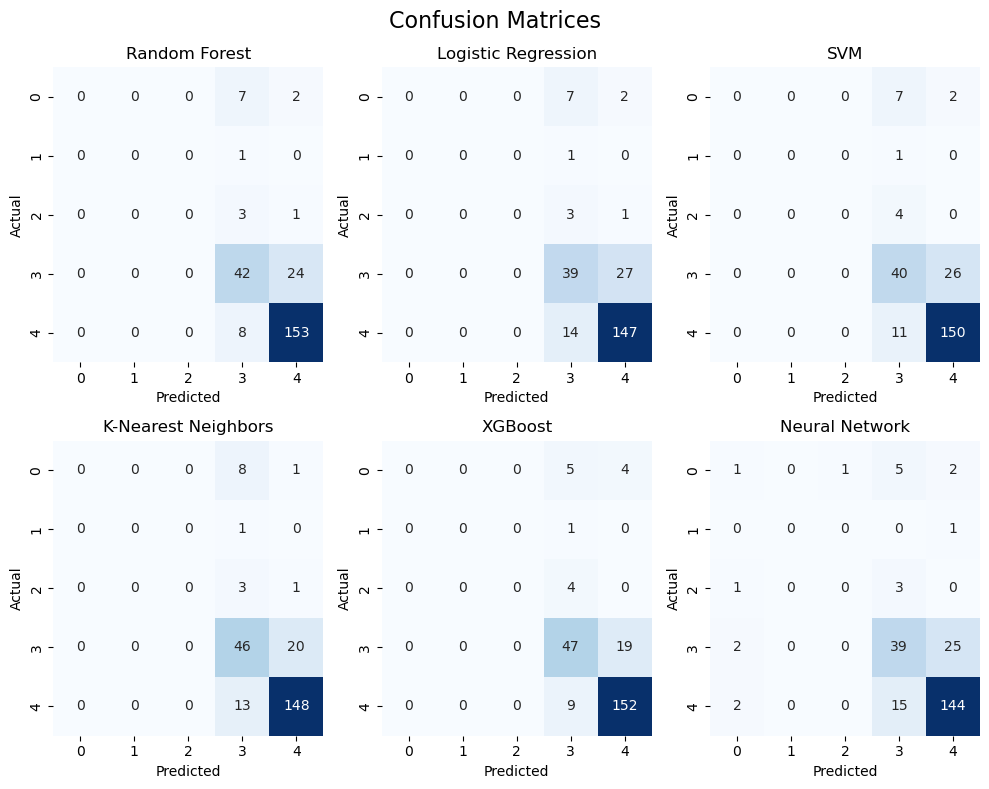

In [97]:
classifier_names = [
    'Random Forest', 'Logistic Regression', 'SVM',
    'K-Nearest Neighbors', 'XGBoost', 'Neural Network'
]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
fig.suptitle('Confusion Matrices', fontsize=16)

axes = axes.ravel()


for i, (cm, name) in enumerate(zip(
    [cm_rf, cm_lr, cm_svc, cm_knn, cm_xgb, cm_nn],
    classifier_names
)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Overall the best F1 score is achieved by XGBoost with parameters {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}.


Next, we evaluate performance using the dataset that uses the full gene subset as features.

In [102]:
best_rf = random_forest(X_train_subset, y_train)
y_pred_rf = best_rf.predict(X_test_subset)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


In [103]:
best_lr = logistic_regression(X_train_subset, y_train)
y_pred_lr = best_lr.predict(X_test_subset)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.

Best Logistic Regression Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


In [105]:
best_svc = svm(X_train_subset, y_train)
y_pred_svc = best_svc.predict(X_test_subset)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc, average='weighted')
recall_svc = recall_score(y_test, y_pred_svc, average='weighted')
f1_svc = f1_score(y_test, y_pred_svc, average='weighted')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [106]:
best_knn = knn(X_train_subset, y_train)
y_pred_knn = best_knn.predict(X_test_subset)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


In [107]:
best_xgb = xgboost(X_train_subset, y_train_encoded)
y_pred_xgb = best_xgb.predict(X_test_subset)

accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test_encoded, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test_encoded, y_pred_xgb, average='weighted')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [108]:
best_nn = neural_netw(X_train_subset, y_train)
y_pred_nn = best_nn.predict(X_test_subset)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn, average='weighted')
recall_nn = recall_score(y_test, y_pred_nn, average='weighted')
f1_nn = f1_score(y_test, y_pred_nn, average='weighted')

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/bio_env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anacond

Best Neural Network Parameters: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}


In [111]:
classifiers = [
    ("Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf),
    ("Logistic Regression", accuracy_lr, precision_lr, recall_lr, f1_lr),
    ("SVM", accuracy_svc, precision_svc, recall_svc, f1_svc),
    ("K-Nearest Neighbors", accuracy_knn, precision_knn, recall_knn, f1_knn),
    ("XGBoost", accuracy_xgb, precision_xgb, recall_xgb, f1_xgb),
    ("Neural Network (MLP)", accuracy_nn, precision_nn, recall_nn, f1_nn)
]

for clf_name, accuracy, precision, recall, f1 in classifiers:
    print(f"{clf_name} Performance:")
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}\n")

Random Forest Performance:
  Accuracy: 0.7801 | Precision: 0.7329 | Recall: 0.7801 | F1 Score: 0.7557

Logistic Regression Performance:
  Accuracy: 0.7801 | Precision: 0.7290 | Recall: 0.7801 | F1 Score: 0.7528

SVM Performance:
  Accuracy: 0.7635 | Precision: 0.7204 | Recall: 0.7635 | F1 Score: 0.7398

K-Nearest Neighbors Performance:
  Accuracy: 0.7718 | Precision: 0.7233 | Recall: 0.7718 | F1 Score: 0.7465

XGBoost Performance:
  Accuracy: 0.7842 | Precision: 0.7419 | Recall: 0.7842 | F1 Score: 0.7625

Neural Network (MLP) Performance:
  Accuracy: 0.7759 | Precision: 0.7499 | Recall: 0.7759 | F1 Score: 0.7615



In [109]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
cm_nn = confusion_matrix(y_test, y_pred_nn)

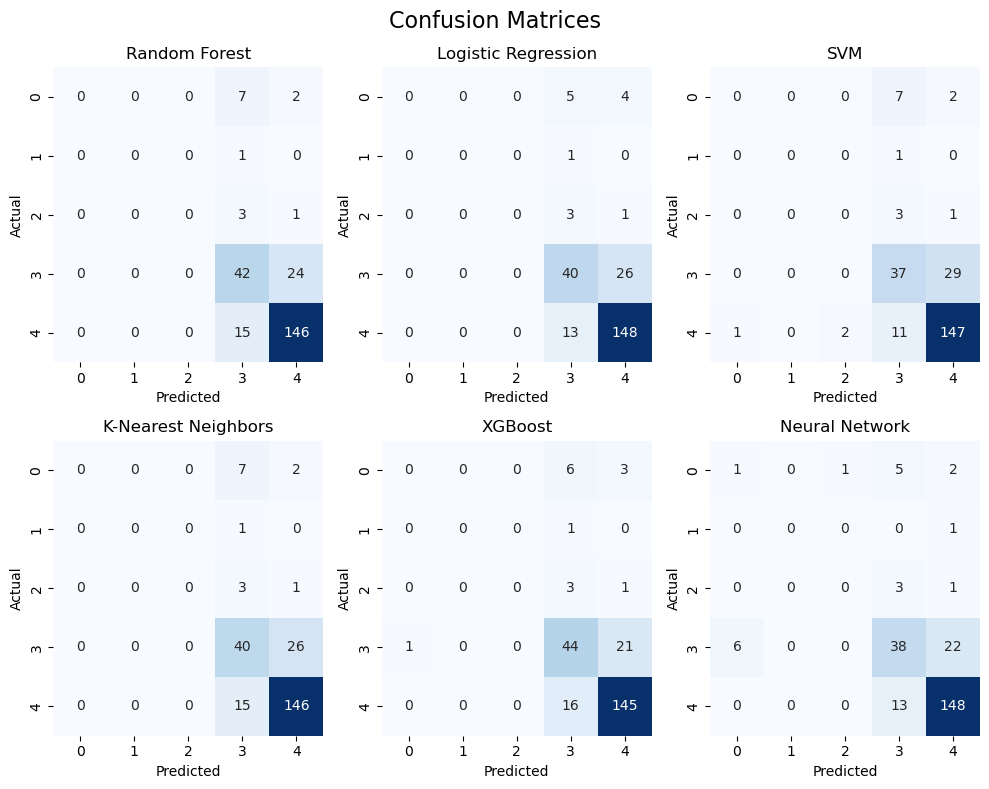

In [110]:
classifier_names = [
    'Random Forest', 'Logistic Regression', 'SVM',
    'K-Nearest Neighbors', 'XGBoost', 'Neural Network'
]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
fig.suptitle('Confusion Matrices', fontsize=16)

axes = axes.ravel()


for i, (cm, name) in enumerate(zip(
    [cm_rf, cm_lr, cm_svc, cm_knn, cm_xgb, cm_nn],
    classifier_names
)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In this second case, the top F1 scores are lower than those achieved by the previously best-performing SVM model. As before, the best overall performance is obtained when using the dataset that includes only the subset of target genes as features, employing XGBoost with parameters {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}.

The overall performance of this model is:

Accuracy: 0.7842 | Precision: 0.7419 | Recall: 0.7842 | F1 Score: 0.7625